# CreditScope Stage 3: governed baseline modelling

This notebook regenerates the locked split and development-only baseline artifacts. The final test set is isolated and is not evaluated. The target is **bad credit risk**, not observed default.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from creditscope.stage3 import generate_stage3_artifacts

summary = generate_stage3_artifacts(PROJECT_ROOT)
summary

{'development_rows_used_for_cv': 800,
 'final_test_rows_isolated': 200,
 'predictive_feature_count': 17,
 'audit_attribute_count': 3,
 'cv_folds': 5,
 'random_state': 42,
 'default_threshold': 0.5,
 'convergence_warnings': 0,
 'figures_created': 4,
 'final_test_performance_evaluated': False,
 'test_rows_used_for_fitting': False,
 'hyperparameter_tuning_performed': False,
 'threshold_optimization_performed': False,
 'resampling_performed': False,
 'class_weight': None,
 'models_trained': ['DummyClassifier', 'LogisticRegression'],
 'split_manifest_sha256': '32fb4c9ac2cdb358e3bffd145cd97e1a393c14946888d46212d0b395523e99af'}

## 1–4. Governance, split, feature separation, and preprocessing

The application-time prediction boundary, sensitive-feature exclusions, proxy-risk assumptions, fixed split, and pipeline-only preprocessing are documented in `docs/modeling_governance.md` and the Stage 3 report.

In [2]:
display(pd.read_csv(PROJECT_ROOT / 'reports/stage3/feature_set_summary.csv'))
display(Markdown((PROJECT_ROOT / 'docs/modeling_governance.md').read_text(encoding='utf-8')))

,feature,role,feature_type,included_in_baseline_prediction
0,duration_months,predictive,numerical,True
1,credit_amount,predictive,numerical,True
2,installment_rate_percent,predictive,numerical,True
3,residence_duration,predictive,numerical,True
4,existing_credits_count,predictive,numerical,True
5,dependents_count,predictive,numerical,True
6,employment_duration,predictive,ordinal categorical,True
7,job,predictive,ordinal categorical,True
8,checking_account_status,predictive,nominal categorical,True
9,credit_history,predictive,nominal categorical,True


# Stage 3 modelling governance

## Decision-support boundary and prediction point

CreditScope remains an educational and research decision-support prototype. The
prediction point is application-time credit-risk assessment, before a lending
decision is made. The target is `bad_credit_risk` (0 = good credit risk, 1 = bad
credit risk); it is not treated as an observed default outcome.

## Direct sensitive and demographic attributes

The predictive feature set excludes `personal_status_sex`, `age_years`, and
`foreign_worker`. These columns remain in the analysis dataset and are retained
separately, aligned by deterministic source-row identifier, for later fairness
and performance auditing.

This is a conservative responsible-AI design choice for this educational
prototype. It is not presented as a jurisdiction-specific legal requirement.

## Potential proxy variables

The baseline retains employment duration, job, housing, property, savings
status, checking-account status, residence duration, dependents, and telephone.
These fields may proxy socioeconomic or demographic circumstances. Retention in
the baseline is not an endorsement for deployment; later sensitivity and
fairness analysis must examine their effects.

## Application-time availability assumption

UCI does not fully document measurement timing. Stage 3 treats the candidate
fields as information available at application time because the source does not
identify them as post-outcome variables. This is an explicit modelling
assumption and dataset limitation, not a claim of certainty. Credit history,
existing credits at this bank, checking and savings status, other installment
plans, and other debtors or guarantors require particular scrutiny.

## Locked baseline scope

- One stratified 80% development / 20% final-test split uses `random_state=42`.
- Final-test labels may be counted to verify stratification, but final-test
  predictive performance is not calculated or inspected in Stage 3.
- Direct sensitive attributes never enter preprocessing or model fitting.
- Potential proxy variables remain candidates pending later analysis.
- Numerical fields use median imputation as inference robustness and standard
  scaling. The verified source currently contains no missing values.
- Nominal categories use one-hot encoding with unknown categories ignored.
- Only employment duration and job use ordinal encoding because their official
  semantics establish an order; source code numbers alone never establish order.
- Unknown/no-account/no-property categories are substantive categories, not
  missing values. Rare categories remain intact.
- Dummy and untuned Logistic Regression baselines use identical five-fold
  stratified development-only cross-validation.
- Logistic Regression uses default `C=1.0`, no class weighting, and a higher
  `max_iter` only to provide convergence headroom.
- All classifications use the fixed 0.50 threshold. No threshold optimization,
  resampling, feature selection, or hyperparameter search occurs.
- UCI cost is oriented with rows as actual class and columns as predicted class:
  false negative (actual bad/predicted good) costs 5; false positive (actual
  good/predicted bad) costs 1.


## 5–8. Dummy and Logistic Regression baselines

Both use identical five-fold stratified development-only CV. Metrics are out-of-fold. The classification threshold remains 0.50, with UCI cost defined as 5 for a bad risk predicted good and 1 for a good risk predicted bad.

In [3]:
comparison = pd.read_csv(PROJECT_ROOT / 'reports/stage3/baseline_comparison.csv')
fold_summary = pd.read_csv(PROJECT_ROOT / 'reports/stage3/cv_metric_summary.csv')
display(comparison)
display(fold_summary)

,model,evaluation_population,threshold,roc_auc,average_precision,precision_bad_credit_risk,recall_bad_credit_risk,f1_bad_credit_risk,balanced_accuracy,brier_score,accuracy,true_negative,false_positive,false_negative,true_positive,false_negative_cost,false_positive_cost,total_cost,average_cost
0,Dummy prior,development out-of-fold predictions,0.5,0.500000,0.300000,0.000000,0.000000,0.0,0.50000,0.210000,0.700,560,0,240,0,5,1,1200,1.500
1,Logistic Regression,development out-of-fold predictions,0.5,0.770112,0.580604,0.576087,0.441667,0.5,0.65119,0.173001,0.735,482,78,134,106,5,1,748,0.935


,model,metric,fold_mean,fold_std
0,Dummy prior,roc_auc,0.500000,0.000000
1,Dummy prior,average_precision,0.300000,0.000000
2,Dummy prior,precision_bad_credit_risk,0.000000,0.000000
3,Dummy prior,recall_bad_credit_risk,0.000000,0.000000
4,Dummy prior,f1_bad_credit_risk,0.000000,0.000000
5,Dummy prior,balanced_accuracy,0.500000,0.000000
6,Dummy prior,brier_score,0.210000,0.000000
7,Dummy prior,accuracy,0.700000,0.000000
8,Dummy prior,default_threshold_total_cost,240.000000,0.000000
9,Dummy prior,default_threshold_average_cost,1.500000,0.000000


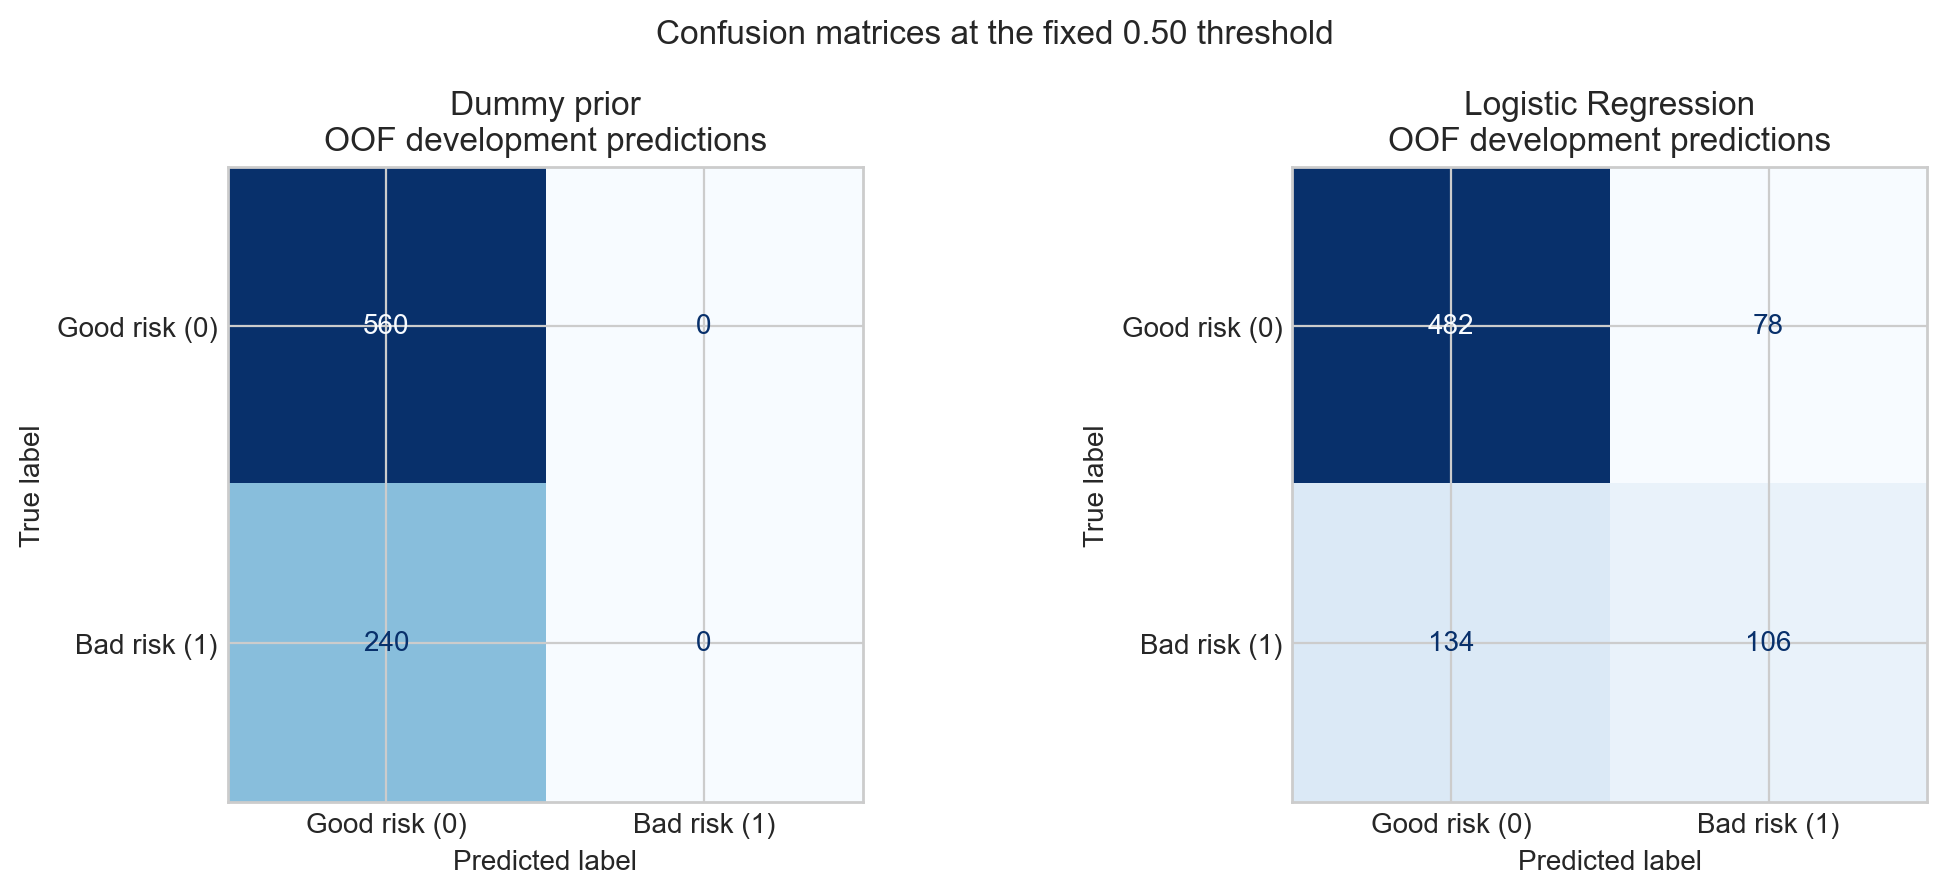

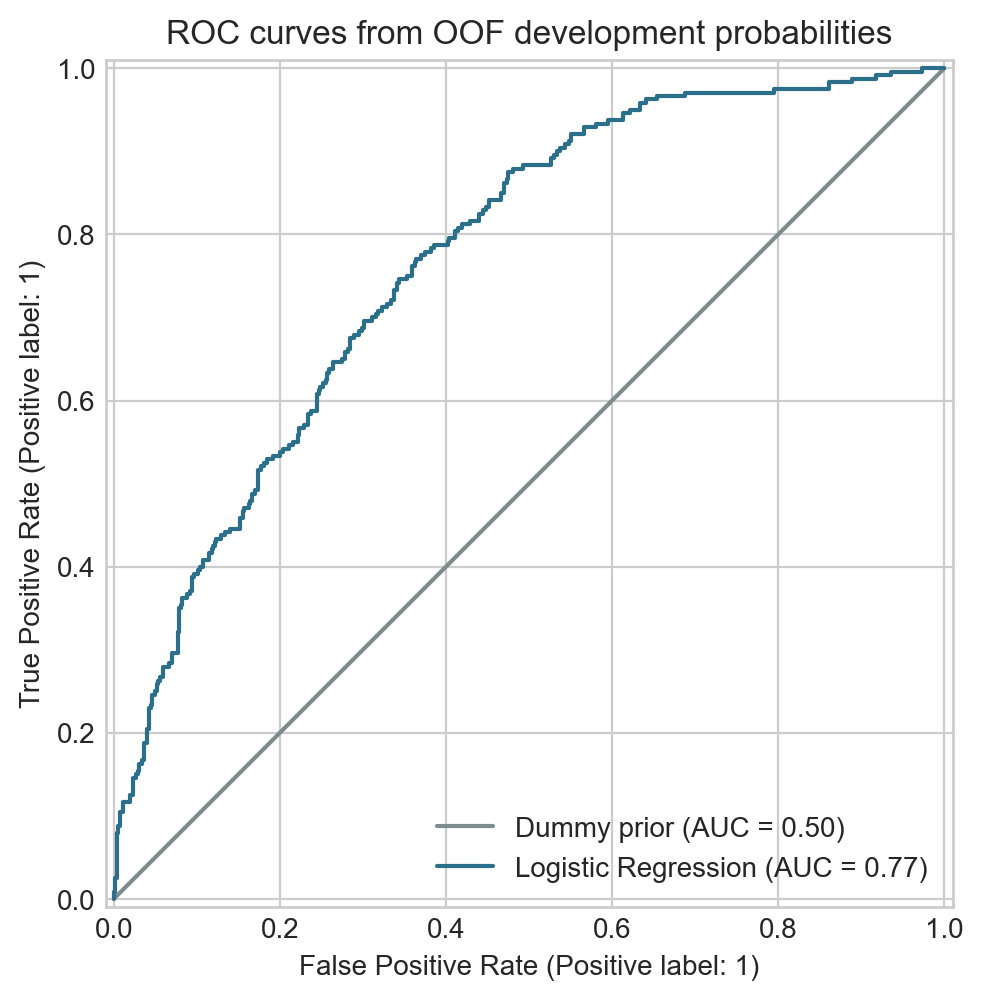

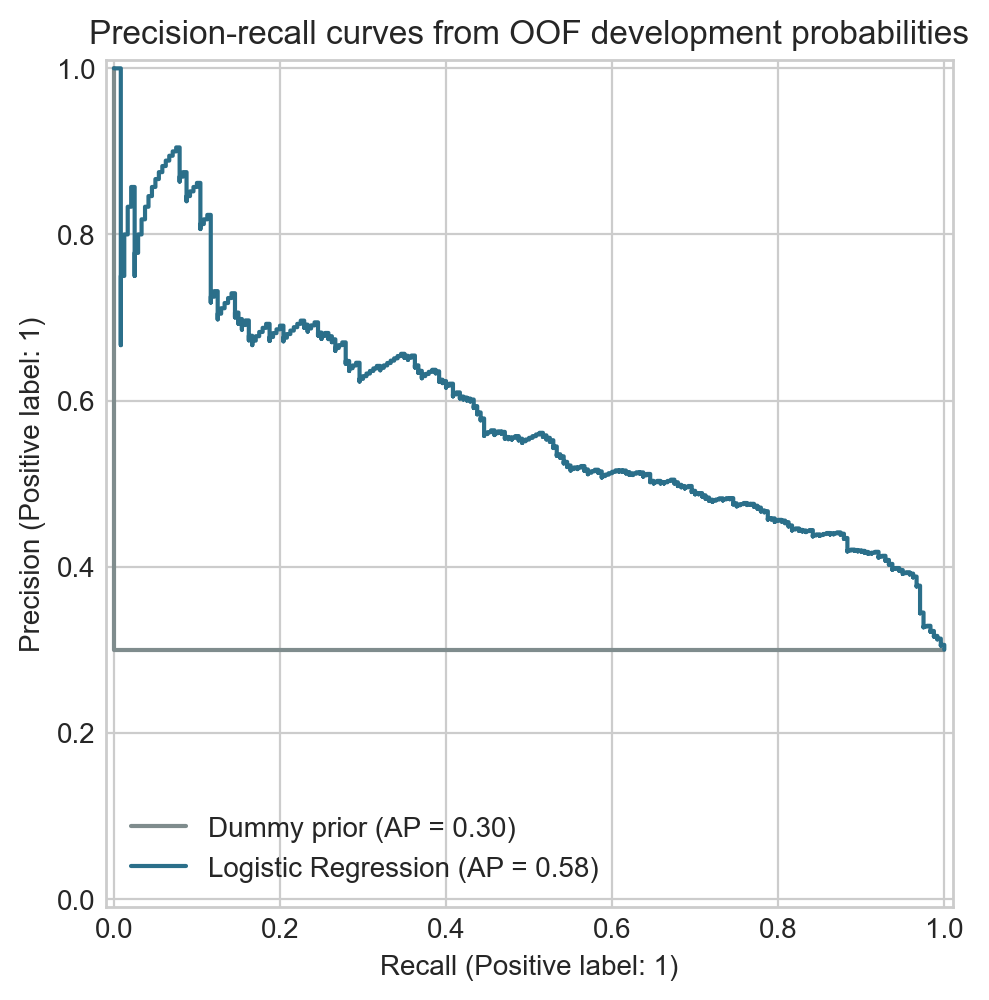

In [4]:
for name in ['confusion_matrices.png', 'roc_curves.png', 'precision_recall_curves.png']:
    display(Image(filename=str(PROJECT_ROOT / 'reports/stage3/figures' / name)))

## 9. Calibration diagnostic

The reliability curve and Brier score diagnose probability quality; no calibration method is fitted.

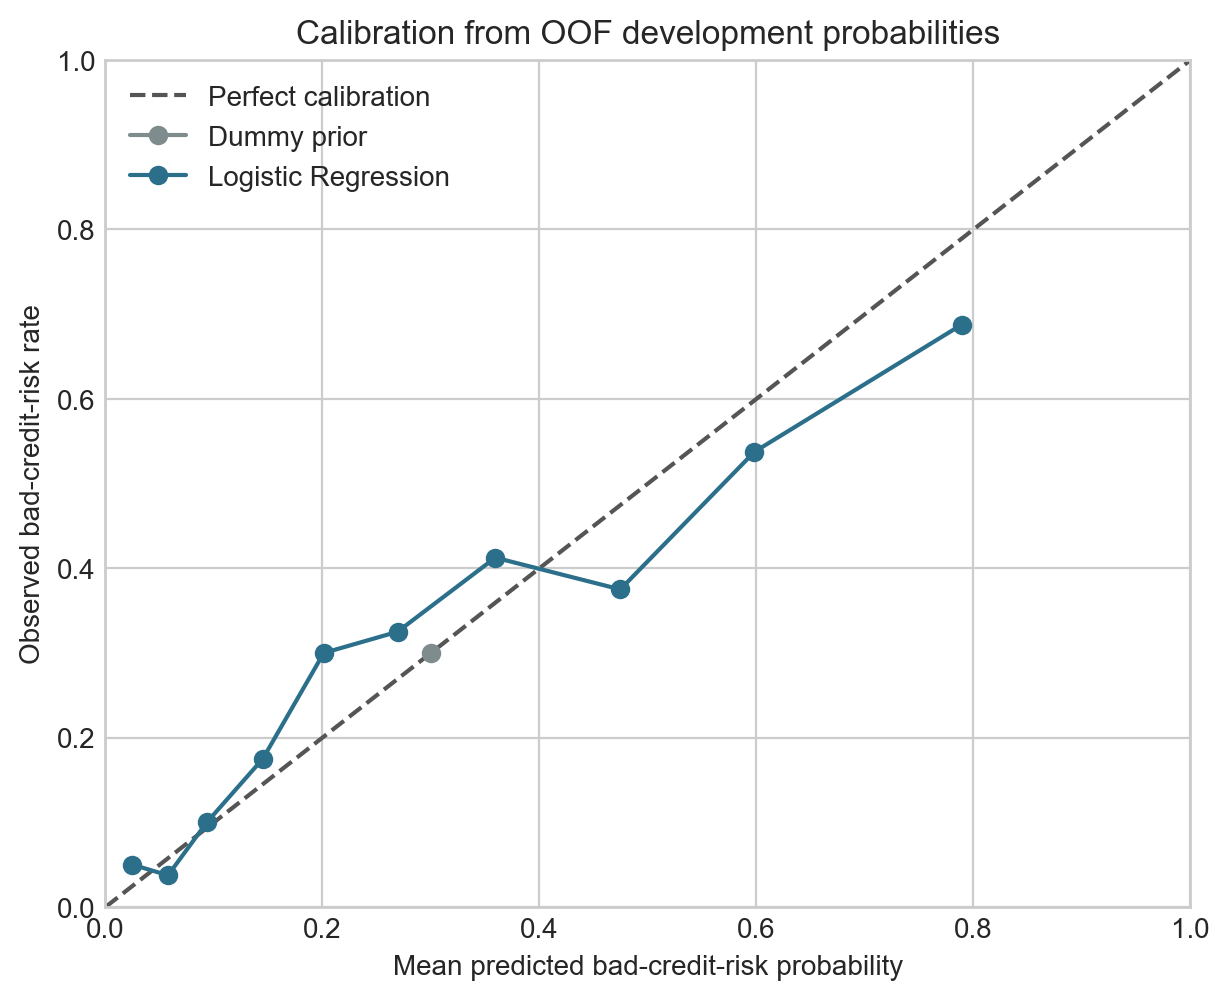

In [5]:
display(Image(filename=str(PROJECT_ROOT / 'reports/stage3/figures/calibration.png')))

## 10. Coefficient interpretation

Coefficients come from a pipeline fitted only on all development rows. They are conditional associations on encoded/scaled terms, not causal effects and not a substitute for later explainability work.

In [6]:
coefficients = pd.read_csv(PROJECT_ROOT / 'reports/stage3/logistic_coefficients.csv')
display(coefficients.head(15))

,transformed_feature,source_feature,coefficient,odds_ratio_exp_coefficient,absolute_coefficient,direction_for_bad_credit_risk_score
0,nominal__purpose_A46,purpose,0.939378,2.558389,0.939378,higher
1,nominal__checking_account_status_A14,checking_account_status,-0.889474,0.410872,0.889474,lower
2,nominal__credit_history_A34,credit_history,-0.810306,0.444722,0.810306,lower
3,nominal__purpose_A41,purpose,-0.699953,0.496609,0.699953,lower
4,nominal__property_A124,property,0.650948,1.917357,0.650948,higher
5,nominal__savings_account_status_A61,savings_account_status,0.646956,1.909719,0.646956,higher
6,nominal__checking_account_status_A11,checking_account_status,0.605487,1.832145,0.605487,higher
7,nominal__housing_A153,housing,-0.597950,0.549938,0.597950,lower
8,nominal__housing_A151,housing,0.592099,1.807780,0.592099,higher
9,nominal__purpose_A410,purpose,-0.568685,0.566270,0.568685,lower


## 11. What remains

Later stages must decide how to compare candidate models, review proxies and subgroup behavior, assess calibration, and select a threshold using development data and the official asymmetric cost. No final model has been selected, and the locked test set remains untouched.